# Homework 5: Local Search – Hill Climbing and Simulated Annealing
**CISC 440 – Artificial Intelligence**  
**Chapter 4 - Local Search Algorithms**

**Due:** See Canvas  
**Submission:** Upload this notebook to Canvas  

**Collaboration Policy:**  
You may work with **one partner (maximum 2 students)**.  
Submit **one notebook per group**.

# Name(s)

1. Ethan Lukandwa
2. Branden Shaffa

## Files Provided

You are provided with the following files:

- `Homework 5.ipynb`
- `search.py`
- `TwinCities Dataset.csv`
- `twin_cities_hub_scores.csv`

# Written Part

Local search algorithms are commonly used for **optimization problems** where the goal is to find a **good solution rather than an exact path**.

In this homework you will apply **Hill Climbing** and **Simulated Annealing** to a **hub placement problem**.

Imagine a logistics company wants to place a **distribution hub in the Twin Cities region**.

The hub location should balance:

- population demand  
- road accessibility  
- traffic congestion  
- distance to major demand zones  

The goal is to **find the best hub location** using local search.


# Question 1 — Local Search Concepts

Answer the following questions.


### 1. Hill Climbing

Explain why Hill Climbing may fail to find the global optimum.

**Hill Climbing may fail to find the global optimum because it only moves to neighboring states that improve the objective function. Once it reaches a state where no neighbor is better, it'll stop. **


### 2. Local Maximum

What is a **local maximum** in the context of hill climbing?

**A local maximum is a state whose value is higher than all of its immediate neighbors, but not necessarily the highest value in the entire search space.**


### 3. Simulated Annealing

Why can simulated annealing escape local maxima while hill climbing cannot?

**It can escape local maxima becaue it occasionally accepts worse solutions with a probability controlled by a temperature parameter. Hill climbing will always reject moves that don't improve the score, so it'll get stuck at the first local peak.**


### 4. Cooling Schedule

Explain the role of the **temperature parameter** in simulated annealing.

**The temperature parameter controls how likely the algorithm is to accept a worse solution.**

### 5. TSP as a Local Search Problem

Why is the Traveling Salesperson Problem a good example of a local search optimization problem?

**It is a good example because the solution space is far too large for exhaustive search, but it's easy to define a neighborhood.**





# Programming Part

In this programming exercise you will:

1. Load city data from **CSV files**
2. Automatically build a **Hub Graph**
3. Define a **Hub Placement Optimization Problem**
4. Define a **Traveling Salesperson Problem**
5. Solve both using:

- Hill Climbing
- Simulated Annealing
- Genetic Algorithm

Important:
Use the provided `search.py` for:

- `Problem`
- `hill_climbing`
- `simulated_annealing`
- `exp_schedule`

For the TSP genetic algorithm, do **not** use the generic GA functions from `search.py`.
Instead, implement your own:
- ordered crossover
- swap mutation
- TSP genetic algorithm runner

You may use these from search.py:
Problem, hill_climbing, simulated_annealing, exp_schedule
You must implement your own TSP genetic algorithm components.

## What You Must Implement

Students must implement the following components:

1. Load city data from CSV files
2. Implement the Euclidean distance function
3. Build the hub graph (citu_coordinates, K)
4. Implement the TwinCitiesHubProblem class
5. Implement the TwinCitiesTSPProblem class
6. Implement the genetic algorithm components:
   - ordered crossover(parent1, parent2)
   - swap mutation (route, pmt)
   - tsp_genetic_alogrithm(...)
7. Run experiments using:
   - hill climbing
   - simulated annealing
   - genetic algorithm

**Important:** For TSP, routes must remain valid permutations of the cities.
Your crossover and mutation operators must not create duplicate cities or omit cities.

# Dataset

Two CSV datasets are provided.

## Dataset 1 — City Coordinates

`TwinCities Dataset.csv`

| City | X | Y |
|-----|---|---|
| Downtown_StPaul | 60 | 90 |
| Midway | 50 | 75 |
| Maplewood | 85 | 75 |

These coordinates represent **relative map locations**.

## Dataset 2 — Hub Feature Scores

`twin_cities_hub_scores.csv`

| city | population_score | road_access | traffic |
|----|----|----|----|
| Downtown_StPaul | 10 | 9 | 9 |
| Midway | 8 | 8 | 6 |

These values represent **factors affecting hub quality**.

# Part A — Load the Data

Load both datasets using **pandas**.

```python
import pandas as pd

cities_df = pd.read_csv("TwinCities Dataset.csv")
scores_df = pd.read_csv("twin_cities_hub_scores.csv")

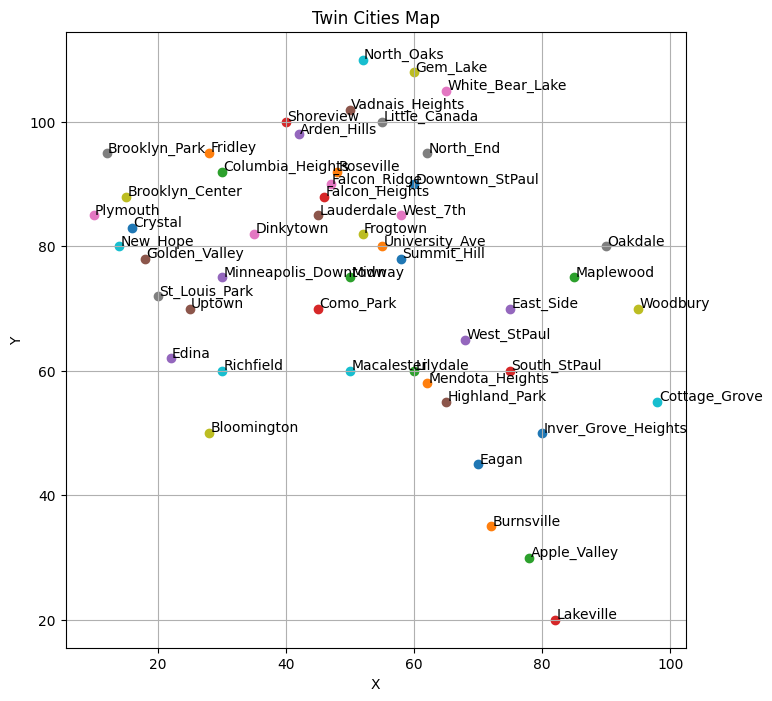

In [25]:
# ============================================================
# Visualization Functions
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt

cities = pd.read_csv("TwinCities Dataset.csv")

plt.figure(figsize=(8,8))

for _, row in cities.iterrows():
    plt.scatter(row["X"], row["Y"])
    plt.text(row["X"]+0.2, row["Y"]+0.2, row["City"])

plt.title("Twin Cities Map")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)

plt.show()


def plot_city_map(city_coordinates, title="Twin Cities Map from CSV"):
    plt.figure(figsize=(10, 8))

    for city, (x, y) in city_coordinates.items():
        plt.scatter(x, y)
        plt.text(x + 0.4, y + 0.4, city, fontsize=8)

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()


def plot_hub_graph(city_coordinates, hub_graph, title="HUB_GRAPH"):
    plt.figure(figsize=(10, 8))

    # Draw edges
    for city, neighbors in hub_graph.items():
        x1, y1 = city_coordinates[city]
        for neighbor in neighbors:
            x2, y2 = city_coordinates[neighbor]
            plt.plot([x1, x2], [y1, y2], alpha=0.5)

    # Draw nodes
    for city in hub_graph:
        x, y = city_coordinates[city]
        plt.scatter(x, y)
        plt.text(x + 0.4, y + 0.4, city, fontsize=8)

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()


def plot_tsp_route(route, city_coordinates, title="TSP Route"):
    xs = [city_coordinates[city][0] for city in route] + [city_coordinates[route[0]][0]]
    ys = [city_coordinates[city][1] for city in route] + [city_coordinates[route[0]][1]]

    plt.figure(figsize=(10, 8))
    plt.plot(xs, ys, marker="o")

    for city in route:
        x, y = city_coordinates[city]
        plt.text(x + 0.4, y + 0.4, city, fontsize=8)

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()

In [26]:
# ============================================================
# Function To run HUB and TSP problem
# ============================================================

def random_route(k=12, seed=1):
    """
    Select k cities for the TSP experiment.
    """
    random.seed(seed)
    chosen = random.sample(list(CITY_COORDINATES.keys()), k)
    return tuple(chosen)


def run_hub_examples():
    print("\n=== HUB PLACEMENT PROBLEM ===")
    starts = ["Midway", "Maplewood", "Minneapolis_Downtown"]

    for start in starts:
        print(f"\nStart: {start}")

        problem = TwinCitiesHubProblem(start)
        hc_solution = hill_climbing(problem)
        print(f"Hill Climbing Result: {hc_solution}")
        print(f"Hub Score: {problem.value(hc_solution):.2f}")

        problem = TwinCitiesHubProblem(start)
        sa_solution = simulated_annealing(
            problem,
            schedule=exp_schedule(k=20, lam=0.01, limit=200)
        )
        print(f"Simulated Annealing Result: {sa_solution}")
        print(f"Hub Score: {problem.value(sa_solution):.2f}")


def run_tsp_examples():
    print("\n=== TSP PROBLEM ===")

    route = random_route(k=12, seed=7)
    tsp = TwinCitiesTSPProblem(route)

    print("\nInitial Route:")
    print_route(route)
    print(f"Initial distance: {tsp.route_length(route):.2f}")

    hc_solution = hill_climbing(tsp)
    print("\nHill Climbing Route:")
    print_route(hc_solution)
    print(f"Hill Climbing distance: {tsp.route_length(hc_solution):.2f}")

    sa_solution = simulated_annealing(
        tsp,
        schedule=exp_schedule(k=30, lam=0.01, limit=500)
    )
    print("\nSimulated Annealing Route:")
    print_route(sa_solution)
    print(f"Simulated Annealing distance: {tsp.route_length(sa_solution):.2f}")

    ga_solution = tsp_genetic_algorithm(
        tsp,
        pop_size=80,
        generations=400,
        pmut=0.2,
        seed=7
    )
    print("\nGenetic Algorithm Route:")
    print_route(ga_solution)
    print(f"Genetic Algorithm distance: {tsp.route_length(ga_solution):.2f}")

Create the following dictionaries:

- `CITY_COORDINATES`
- `POPULATION_SCORE`
- `ROAD_ACCESS`
- `TRAFFIC`

Example:

```python
CITY_COORDINATES["Midway"] = (50, 75)

In [27]:
import pandas as pd

cities_df = pd.read_csv("TwinCities Dataset.csv")
scores_df = pd.read_csv("twin_cities_hub_scores(50 cities).csv")


# Maps city name -> (x, y) tuple
CITY_COORDINATES = {
    row["City"]: (row["X"], row["Y"])
    for _, row in cities_df.iterrows()
}

# Maps city name -> population score
POPULATION_SCORE = {
    row["city"]: row["population_score"]
    for _, row in scores_df.iterrows()
}

# Maps city name -> road accessibility score
ROAD_ACCESS = {
    row["city"]: row["road_access"]
    for _, row in scores_df.iterrows()
}

# Maps city name -> traffic congestion score
TRAFFIC = {
    row["city"]: row["traffic"]
    for _, row in scores_df.iterrows()
}


In [8]:
print(TRAFFIC) # Example

{'Downtown_StPaul': 9, 'University_Ave': 8, 'Midway': 6, 'Como_Park': 4, 'East_Side': 5, 'Highland_Park': 3, 'West_7th': 7, 'North_End': 5, 'Frogtown': 6, 'Macalester': 4, 'Summit_Hill': 5, 'Roseville': 5, 'Maplewood': 4, 'Falcon_Heights': 3, 'Minneapolis_Downtown': 10, 'Lauderdale': 3, 'Oakdale': 3, 'Woodbury': 4, 'Mendota_Heights': 3, 'Lilydale': 2, 'Little_Canada': 3, 'Shoreview': 3, 'West_StPaul': 4, 'South_StPaul': 4, 'Uptown': 8, 'Dinkytown': 7, 'Cottage_Grove': 3, 'Eagan': 4}


## Part B — Distance Function

Implement the Euclidean distance function.
```python
distance(city1, city2)

#equation: 
sqrt((x1-x2)^2 + (y1-y2)^2)

In [28]:
import math

def distance(city1, city2):
    x1, y1 = CITY_COORDINATES[city1]
    x2, y2 = CITY_COORDINATES[city2]
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

In [11]:
print(distance("Midway", "Downtown_StPaul"))

18.027756377319946


## Part C — Build the Hub Graph

You must automatically construct the Hub Graph.

The graph represents possible local moves between hub locations.

Each city should be connected to its k nearest neighbors based on distance.

Use:
```python
K = 3

#Example graph structure:
HUB_GRAPH = {
    "Midway": ["University_Ave", "Como_Park", "Macalester"],
    "Maplewood": ["Oakdale", "Woodbury", "East_Side"]
}



In [29]:
K = 3

def build_hub_graph(city_coordinates, k):
    hub_graph = {}

    for city in city_coordinates:
        # Calculate distance from this city to every other city
        distances = [
            (other, distance(city, other))
            for other in city_coordinates
            if other != city
        ]

        # Sort by distance and take the k closest
        distances.sort(key=lambda x: x[1])
        hub_graph[city] = [neighbor for neighbor, _ in distances[:k]]

    return hub_graph


HUB_GRAPH = build_hub_graph(CITY_COORDINATES, K)

In [30]:
# Each city should have exactly K neighbors
print(HUB_GRAPH["Midway"])       
print(len(HUB_GRAPH["Midway"]))  

# Quick check that all cities are present
print(len(HUB_GRAPH) == len(CITY_COORDINATES))  

['University_Ave', 'Como_Park', 'Frogtown']
3
True


### Task

Implement the function: build_hub_graph(city_coordinates, k)

Steps:

1. For each city
2. Compute distance to every other city
3. Sort neighbors by distance
4. Select the k closest neighbors

In [31]:
K = 3

def build_hub_graph(city_coordinates, k):
    hub_graph = {}

    for city in city_coordinates:
        # Calculate distance from this city to every other city
        distances = [
            (other, distance(city, other))
            for other in city_coordinates
            if other != city
        ]

        # Sort by distance and take the k closest
        distances.sort(key=lambda x: x[1])
        hub_graph[city] = [neighbor for neighbor, _ in distances[:k]]

    return hub_graph


HUB_GRAPH = build_hub_graph(CITY_COORDINATES, K)

In [32]:
print("Build HUB_GRAPH (first 10 cities)")
print(f"Downtown_StPaul: {HUB_GRAPH["Downtown_StPaul"]}")
print(f"University_Ave: {HUB_GRAPH["University_Ave"]}")
print(HUB_GRAPH["Midway"])
print(HUB_GRAPH["Como_Park"])
print(HUB_GRAPH["East_Side"])
print(HUB_GRAPH["Highland_Park"])
print(HUB_GRAPH["West_7th"])
print(HUB_GRAPH["North_End"])
print(HUB_GRAPH["Frogtown"])
print(HUB_GRAPH["Macalester"])


Build HUB_GRAPH (first 10 cities)
Downtown_StPaul: ['West_7th', 'North_End', 'University_Ave']
University_Ave: ['Frogtown', 'Summit_Hill', 'West_7th']
['University_Ave', 'Como_Park', 'Frogtown']
['Midway', 'Macalester', 'Frogtown']
['West_StPaul', 'South_StPaul', 'Maplewood']
['Mendota_Heights', 'Lilydale', 'West_StPaul']
['Downtown_StPaul', 'University_Ave', 'Frogtown']
['Downtown_StPaul', 'Little_Canada', 'White_Bear_Lake']
['University_Ave', 'West_7th', 'Summit_Hill']
['Lilydale', 'Como_Park', 'Mendota_Heights']


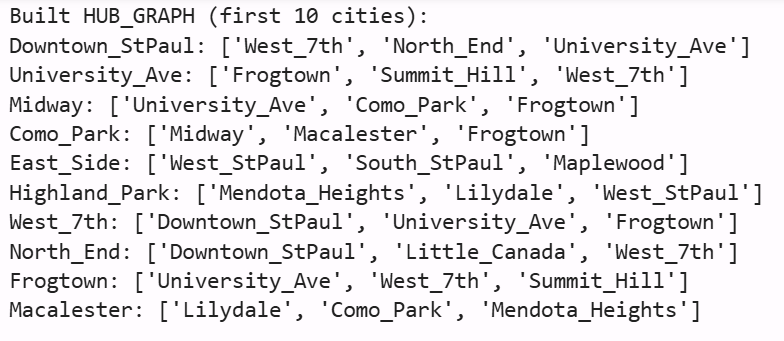

## Part D — Hub Placement Problem

Create a class:

`TwinCitiesHubProblem(Problem)`

### State
A city name.

### Actions
Neighbor cities from `HUB_GRAPH`.

### Result
Move to the selected neighbor city.



### Value Function for Hub Placement

The goal is to **maximize hub quality**.

Use the scoring function:

`value = 3 * population_score + 2 * road_access - 2.5 * traffic - 0.15 * average_distance_to_demand_zones`


### Demand Zones
- Downtown_StPaul
- University_Ave
- Midway
- East_Side
- Minneapolis_Downtown
- Roseville
- Maplewood
- Woodbury


Higher value = **better hub location**.


In [33]:
from search import Problem, hill_climbing, simulated_annealing, exp_schedule

DEMAND_ZONES = [
    "Downtown_StPaul",
    "University_Ave",
    "Midway",
    "East_Side",
    "Minneapolis_Downtown",
    "Roseville",
    "Maplewood",
    "Woodbury"
]

class TwinCitiesHubProblem(Problem):

    def __init__(self, initial):
        super().__init__(initial)

    def actions(self, state):
        # Neighbors from the hub graph are the possible moves
        return HUB_GRAPH[state]

    def result(self, state, action):
        # Moving to a neighbor city is the new state
        return action

    def value(self, state):
        pop    = POPULATION_SCORE[state]
        road   = ROAD_ACCESS[state]
        traffic = TRAFFIC[state]

        # Average distance from this city to all demand zones
        avg_dist = sum(distance(state, zone)
                       for zone in DEMAND_ZONES) / len(DEMAND_ZONES)

        return (3 * pop) + (2 * road) - (2.5 * traffic) - (0.15 * avg_dist)

## Part E — Run Hill Climbing and Simulated Annealing for Hub Placement

Run **Hill Climbing** on the hub placement problem.

Use **three different starting cities**:

1. Midway
2. Maplewood
3. Minneapolis_Downtown

Print:

- Start city  
- Final hub location  
- Hub score  

### Example Output
Start: Midway

Hill Climbing Result: Midway

Hub Score: 21.85

Simulated Annealing Result: Frogtown

Hub Score: 19.99


Now run **Simulated Annealing** using the schedule:
    exp_schedule(k=20, lam=0.01, limit=200)

Print:

- Start city  
- Final hub location  
- Hub score  


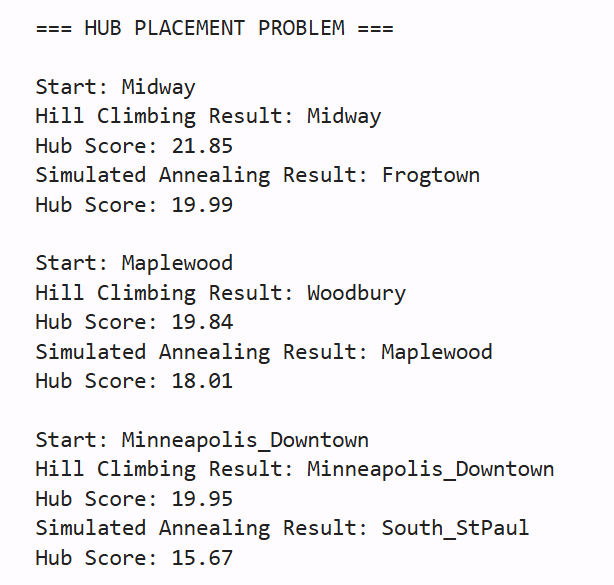

In [34]:
def run_hub_examples():
    print("\n=== HUB PLACEMENT PROBLEM ===")
    starts = ["Midway", "Maplewood", "Minneapolis_Downtown"]

    for start in starts:
        print(f"\nStart: {start}")

        # Hill Climbing
        problem = TwinCitiesHubProblem(start)
        hc_solution = hill_climbing(problem)
        print(f"Hill Climbing Result: {hc_solution}")
        print(f"Hub Score: {problem.value(hc_solution):.2f}")

        # Simulated Annealing
        problem = TwinCitiesHubProblem(start)
        sa_solution = simulated_annealing(
            problem,
            schedule=exp_schedule(k=20, lam=0.01, limit=200)
        )
        print(f"Simulated Annealing Result: {sa_solution}")
        print(f"Hub Score: {problem.value(sa_solution):.2f}")

run_hub_examples()


=== HUB PLACEMENT PROBLEM ===

Start: Midway
Hill Climbing Result: University_Ave
Hub Score: 20.06
Simulated Annealing Result: University_Ave
Hub Score: 20.06

Start: Maplewood
Hill Climbing Result: Woodbury
Hub Score: 20.79
Simulated Annealing Result: Oakdale
Hub Score: 18.97

Start: Minneapolis_Downtown
Hill Climbing Result: Minneapolis_Downtown
Hub Score: 19.30
Simulated Annealing Result: Roseville
Hub Score: 21.39


## Part F — Traveling Salesperson Problem (TSP)

In this part, you will use the same **Twin Cities coordinate dataset** to define a **Traveling Salesperson Problem (TSP)**.

The goal is to find a route that:

- visits every selected city **exactly once**
- returns to the **starting city**
- **minimizes the total route length**



### Step 1 — Select Cities for TSP

Select a subset of cities for the TSP experiment.

Use:
Use **12 cities**.


You may either:

- choose the **first 12 cities** from the dataset, or  
- **randomly select 12 cities**

Store the route as a **tuple or list**.

Example:

```python
initial_route = (
    "Downtown_StPaul",
    "University_Ave",
    "Midway",
    ...
)


In [37]:
initial_route = tuple(list(CITY_COORDINATES.keys())[:12]) #Selecting the first 12 cities from dataset.

Selected cities: ('Downtown_StPaul', 'University_Ave', 'Midway', 'Como_Park', 'East_Side', 'Highland_Park', 'West_7th', 'North_End', 'Frogtown', 'Macalester', 'Summit_Hill', 'Roseville')


### Step 2 — Define the TSP Problem

Create a class:

`TwinCitiesTSPProblem(Problem)`

#### State

A complete route (ordering of cities).

#### Actions

Define neighborhood operations that modify the route. You may use one or both of the following:

- swap(i, j)      swap two cities
- reverse(i, j)   reverse a segment of the route
- Result

Return the modified route after applying the selected action.

#### Value Function for TSP

The goal is to minimize total route length.

Because the search package maximizes value(state), define:

`value(state) = -1 * route_length(state)`

where:

`route_length(route)`

Computes the total Euclidean distance of the full closed tour.

A closed tour means the route must return to the starting city.

In [ ]:
class TwinCitiesTSPProblem(Problem):

    def __init__(self, initial):
        super().__init__(initial)

    def actions(self, state):
        # Generate all possible swap(i,j) and reverse(i,j) pairs
        n = len(state)
        moves = []

        for i in range(n):
            for j in range(i + 1, n):
                moves.append(("swap", i, j))
                moves.append(("reverse", i, j))

        return moves

    def result(self, state, action):
        route = list(state)
        move, i, j = action

        if move == "swap":
            # Swap i and j
            route[i], route[j] = route[j], route[i]

        elif move == "reverse":
            # Reverse the segment between i and j
            route[i:j+1] = route[i:j+1][::-1]

        return tuple(route)

    def route_length(self, route):
        total = 0
        n = len(route)

        for i in range(n):
            city1 = route[i]
            #wrap around to start
            city2 = route[(i + 1) % n]  
            total += distance(city1, city2)

        return total

    def value(self, state):
        # Negate 
        return -1 * self.route_length(state)

## Part G — Run Hill Climbing and Simulated Annealing for TSP

Using your initial TSP route:

- Print the initial route
- Print the initial route distance
- Run Hill Climbing
- Print the final route and final distance
- Run Simulated Annealing
- Print the final route and final distance

Use the schedule:

`exp_schedule(k=30, lam=0.01, limit=500)`

Example Output

Initial distance: 412.57

Hill Climbing distance: 301.44

Simulated Annealing distance: 286.12

In [ ]:
def print_route(route):
    print(" -> ".join(route) + " -> " + route[0])


def run_tsp_examples():
    print("\n=== TSP PROBLEM ===")

    route = random_route(k=12, seed=7)
    tsp = TwinCitiesTSPProblem(route)

    # Initial route
    print("\nInitial Route:")
    print_route(route)
    print(f"Initial distance: {tsp.route_length(route):.2f}")

    # Hill Climbing
    hc_solution = hill_climbing(tsp)
    print("\nHill Climbing Route:")
    print_route(hc_solution)
    print(f"Hill Climbing distance: {tsp.route_length(hc_solution):.2f}")

    # Simulated Annealing
    tsp = TwinCitiesTSPProblem(route)  
    sa_solution = simulated_annealing(
        tsp,
        schedule=exp_schedule(k=30, lam=0.01, limit=500)
    )
    print("\nSimulated Annealing Route:")
    print_route(sa_solution)
    print(f"Simulated Annealing distance: {tsp.route_length(sa_solution):.2f}")

    # Genetic Algorithm
    tsp = TwinCitiesTSPProblem(route)
    ga_solution = tsp_genetic_algorithm(
        tsp,
        pop_size=80,
        generations=400,
        pmut=0.2,
        seed=7
    )
    print("\nGenetic Algorithm Route:")
    print_route(ga_solution)
    print(f"Genetic Algorithm distance: {tsp.route_length(ga_solution):.2f}")




run_tsp_examples()


=== TSP PROBLEM ===

Initial Route:
Eagan -> Macalester -> Golden_Valley -> Mendota_Heights -> Como_Park -> East_Side -> Arden_Hills -> West_7th -> Lakeville -> Oakdale -> Lauderdale -> Columbia_Heights -> Eagan
Initial distance: 478.12

Hill Climbing Route:
Lakeville -> East_Side -> Oakdale -> West_7th -> Lauderdale -> Arden_Hills -> Columbia_Heights -> Golden_Valley -> Como_Park -> Macalester -> Mendota_Heights -> Eagan -> Lakeville
Hill Climbing distance: 253.60

Simulated Annealing Route:
Macalester -> Mendota_Heights -> Eagan -> Lakeville -> Oakdale -> East_Side -> West_7th -> Lauderdale -> Arden_Hills -> Columbia_Heights -> Golden_Valley -> Como_Park -> Macalester
Simulated Annealing distance: 253.93


## Part H — Genetic Algorithm for TSP

In this part, you will implement a **Genetic Algorithm (GA)** to solve the Traveling Salesperson Problem.

Genetic Algorithms are inspired by **biological evolution** and use the following concepts:

- population
- selection
- crossover
- mutation
- generations

The goal is to evolve better routes over time.


### Step 1 — Initial Population

Create an **initial population of random routes**.

Each individual in the population should be a **permutation of the selected cities**.

Example population:

[
("Midway","Roseville","Maplewood",...),

("Roseville","Midway","Minneapolis_Downtown",...),

("Maplewood","Midway","Roseville",...)

]

Use a population size such as:

pop_size = 60


### Step 2 — Fitness Function

The fitness function evaluates the quality of each route.

Because shorter routes are better, define fitness as:

fitness(route) = -route_length(route)

This ensures that routes with **shorter distances have higher fitness**.

### Step 3 — Selection

Use **roulette-wheel selection** to choose parents for reproduction.

Parents with higher fitness should have **higher probability of selection**.

### Step 4 — Crossover

Because TSP routes are **permutations**, you must use a **permutation-safe crossover operator**.

Use **Ordered Crossover (OX)**:

1. Randomly select two cut points
2. Copy the segment from Parent 1
3. Fill the remaining cities using the order from Parent 2

Example:

Parent 1: A B C D E F
Parent 2: C F B A D E

Child after crossover preserves valid city order.

### Step 5 — Mutation

Apply **swap mutation** with a small probability.

Mutation operation:

swap(i, j)

This swaps two cities in the route.

Example:


A B C D E
→ swap(1,3)
A D C B E

Suggested mutation probability:


pmut = 0.2


### Step 6 — Run the Genetic Algorithm

Run the GA for multiple generations.

Suggested parameters:


population size = 80
generations = 400
mutation probability = 0.2


At each generation:

1. Evaluate fitness
2. Select parents
3. Apply crossover
4. Apply mutation
5. Form the next generation

Track the **best route found**.

### Step 7 — Print Results

Print:

- Best route found
- Total distance of that route

Example output:


Genetic Algorithm Route:
Midway -> Roseville -> Maplewood -> ... -> Midway

Genetic Algorithm distance: 278.43

**Important:** In TSP, each route must remain a valid permutation of the selected cities.
A route must not contain duplicate cities, and no city should be missing.
Your crossover and mutation operators must preserve valid routes.

```python
def tsp_genetic_algorithm(problem, pop_size=80, generations=400, pmut=0.2, seed=42):
    """
    Custom GA for permutation-based TSP.

    Args:
        problem: TwinCitiesTSPProblem
        pop_size: number of individuals
        generations: number of generations
        pmut: mutation probability
        seed: random seed

    Returns:
        best route found
    """
    random.seed(seed)

    cities = list(problem.initial)
    n = len(cities)

    # Initial population of random permutations
    population = [tuple(random.sample(cities, n)) for _ in range(pop_size)]

    best = max(population, key=problem.value)

    for gen in range(generations):
        raw_scores = [problem.value(ind) for ind in population]

        # Shift scores so fitness is positive
        min_score = min(raw_scores)
        fitness = [score - min_score + 1 for score in raw_scores]

        current_best = max(population, key=problem.value)
        if problem.value(current_best) > problem.value(best):
            best = current_best

        new_population = []
        for _ in range(pop_size):
            parent1 = random.choices(population, weights=fitness, k=1)[0]
            parent2 = random.choices(population, weights=fitness, k=1)[0]

            child = ordered_crossover(parent1, parent2)
            child = swap_mutation(child, pmut)

            new_population.append(child)

        population = new_population

    return best



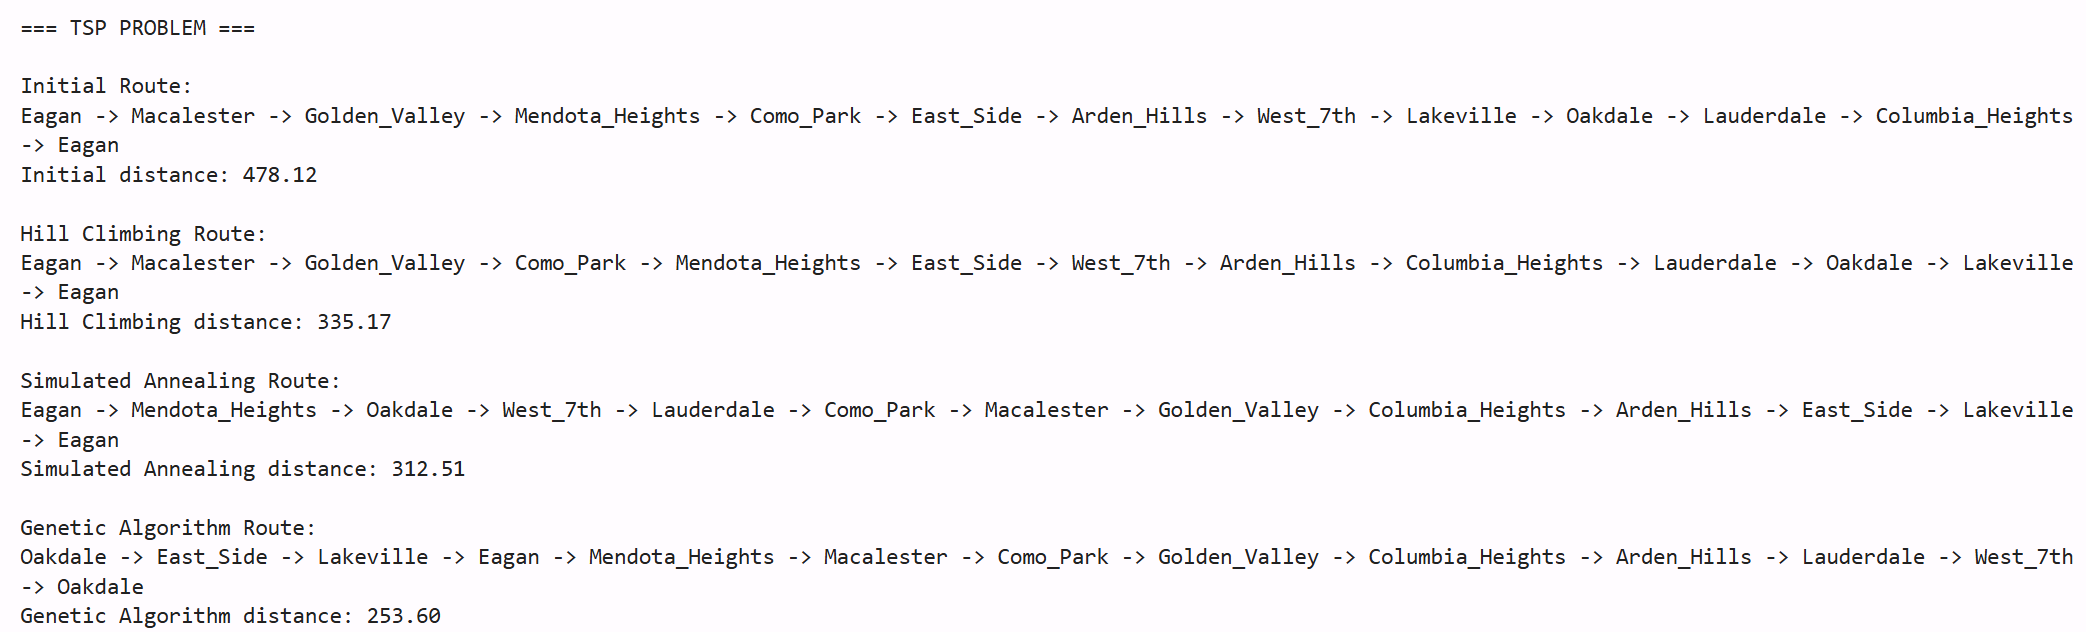

In [ ]:
import random

def ordered_crossover(parent1, parent2):
    n = len(parent1)

    #Pick two random cut points
    i, j = sorted(random.sample(range(n), 2))

    # Step 2:
    child = [None] * n
    child[i:j+1] = parent1[i:j+1]

    #Fill remaining positions using parent2's order
    segment = set(parent1[i:j+1])
    remaining = [city for city in parent2 if city not in segment]

    pos = 0
    for k in range(n):
        if child[k] is None:
            child[k] = remaining[pos]
            pos += 1

    return tuple(child)


def swap_mutation(route, pmut):
    if random.random() < pmut:
        route = list(route)
        i, j = random.sample(range(len(route)), 2)
        route[i], route[j] = route[j], route[i]
        return tuple(route)
    return route


def tsp_genetic_algorithm(problem, pop_size=80, generations=400, pmut=0.2, seed=42):
    random.seed(seed)

    cities = list(problem.initial)
    n = len(cities)

    # Initial population of random permutations
    population = [tuple(random.sample(cities, n)) for _ in range(pop_size)]

    best = max(population, key=problem.value)

    for gen in range(generations):
        raw_scores = [problem.value(ind) for ind in population]

        # Shift scores so all fitness values are positive for roulette wheel
        min_score = min(raw_scores)
        fitness = [score - min_score + 1 for score in raw_scores]

        # Track best route found so far
        current_best = max(population, key=problem.value)
        if problem.value(current_best) > problem.value(best):
            best = current_best

        # Build next generation
        new_population = []
        for _ in range(pop_size):
            parent1 = random.choices(population, weights=fitness, k=1)[0]
            parent2 = random.choices(population, weights=fitness, k=1)[0]

            child = ordered_crossover(parent1, parent2)
            child = swap_mutation(child, pmut)

            new_population.append(child)

        population = new_population

    return best

In [45]:
def print_route(route):
    print(" -> ".join(route) + " -> " + route[0])


def run_tsp_examples():
    print("\n=== TSP PROBLEM ===")

    route = random_route(k=12, seed=7)
    tsp = TwinCitiesTSPProblem(route)

    # Initial route
    print("\nInitial Route:")
    print_route(route)
    print(f"Initial distance: {tsp.route_length(route):.2f}")

    # Hill Climbing
    hc_solution = hill_climbing(tsp)
    print("\nHill Climbing Route:")
    print_route(hc_solution)
    print(f"Hill Climbing distance: {tsp.route_length(hc_solution):.2f}")

    # Simulated Annealing
    tsp = TwinCitiesTSPProblem(route)  
    sa_solution = simulated_annealing(
        tsp,
        schedule=exp_schedule(k=30, lam=0.01, limit=500)
    )
    print("\nSimulated Annealing Route:")
    print_route(sa_solution)
    print(f"Simulated Annealing distance: {tsp.route_length(sa_solution):.2f}")

    # Genetic Algorithm
    tsp = TwinCitiesTSPProblem(route)  # fresh instance
    ga_solution = tsp_genetic_algorithm(
        tsp,
        pop_size=80,
        generations=400,
        pmut=0.2,
        seed=7
    )
    print("\nGenetic Algorithm Route:")
    print_route(ga_solution)
    print(f"Genetic Algorithm distance: {tsp.route_length(ga_solution):.2f}")




run_tsp_examples()


=== TSP PROBLEM ===

Initial Route:
Eagan -> Macalester -> Golden_Valley -> Mendota_Heights -> Como_Park -> East_Side -> Arden_Hills -> West_7th -> Lakeville -> Oakdale -> Lauderdale -> Columbia_Heights -> Eagan
Initial distance: 478.12

Hill Climbing Route:
Lakeville -> East_Side -> Oakdale -> West_7th -> Lauderdale -> Arden_Hills -> Columbia_Heights -> Golden_Valley -> Como_Park -> Macalester -> Mendota_Heights -> Eagan -> Lakeville
Hill Climbing distance: 253.60

Simulated Annealing Route:
Macalester -> Mendota_Heights -> Eagan -> Lakeville -> Oakdale -> East_Side -> West_7th -> Lauderdale -> Arden_Hills -> Columbia_Heights -> Golden_Valley -> Como_Park -> Macalester
Simulated Annealing distance: 253.93

Genetic Algorithm Route:
Oakdale -> East_Side -> Lakeville -> Eagan -> Mendota_Heights -> Macalester -> Como_Park -> Golden_Valley -> Columbia_Heights -> Arden_Hills -> Lauderdale -> West_7th -> Oakdale
Genetic Algorithm distance: 253.60


## Part I — Comparison Questions for Hub and TSP

Answer the following questions.

1. Did Hill Climbing always find the same hub location?

**No it didn't. Starting at Midway it foujnd University Ave which was 20.06, from Maplewood it found Woodbury, from Minneapolis Downtown it stayed at Minneapolis Downtown 19.30.**

2. Did Simulated Annealing produce better hub solutions?

**Simulated annealing results were mixed depending on the starting city. From Midway both algorithms found the same spot. From Minneapolis Downtown simulated annealing did better, finding Roseville 21.39 vs HC staying put at 19.30. From Maplewood HC actually won, landing on Woodbury 20.79 while SA wandered to Oakdale 18.97. So SA isn't always better but it did find the overall best location of the three starting points.**

3. For the TSP problem, did the route distance improve after local search?

**Yes, the initial random route distance of 478.12 improved dramatically after local search. Hill Climbing reduced it to 253.60, nearly cutting the distance in half.**

4. Did Simulated Annealing produce a shorter TSP route than Hill Climbing?

**No, hill climbing 253.60 slightly outperformed simulated annealing 253.9 in this case, with a difference of only 0.33 units. The genetic algorithm also matched hill climbing at 253.60.**

5. Why might simulated annealing perform better than hill climbing for TSP?

**tsp has really large search space with many local optima, hill climbing gets permanently stuck at the first one it finds. Simulated annealing can escape by occasionally accepting worse routess early on when temperature is high**

## Part J — Final Algorithm Comparison

Compare the three optimization methods used for TSP:

- Hill Climbing
- Simulated Annealing
- Genetic Algorithm

Answer the following questions.

1. Which algorithm produced the **shortest TSP route**?

**Hill Climbing and Genetic Algorithm**


2. Did Hill Climbing get stuck in a **local optimum**?

**maybe. the fact that all three algorithms converged around 253.60 suggests this may be near-optimal for these 12 cities, so it's hard to say definitively. However Hill Climbing is always vulnerable to local optima since it never backtracks, so it likely got lucky here with a good starting route.**


3. How did Simulated Annealing improve upon Hill Climbing?

**According to my data SA finished slightly worse at 253.93 vs 253.6. Maybe if I put more generations or a slower cooling schedule it would match or beat HC**


4. Did the Genetic Algorithm produce a better solution than the other methods?

**It matched HC at 253.6 but it didn't beat it. So no it did not**


5. Why are Genetic Algorithms particularly useful for **permutation problems like TSP**?

**TSP routes are permutations, which means you can't just randomly change the values without breaking the solutions. GA handles this naturally through operators (ordered crossover and swap mutations). It also searches many routes simultaneously rather than one at a time.**

### Visualize the TSP route using matplotlib.

Your visualization should:

• plot all cities  
• draw the TSP route  
• return to the starting city

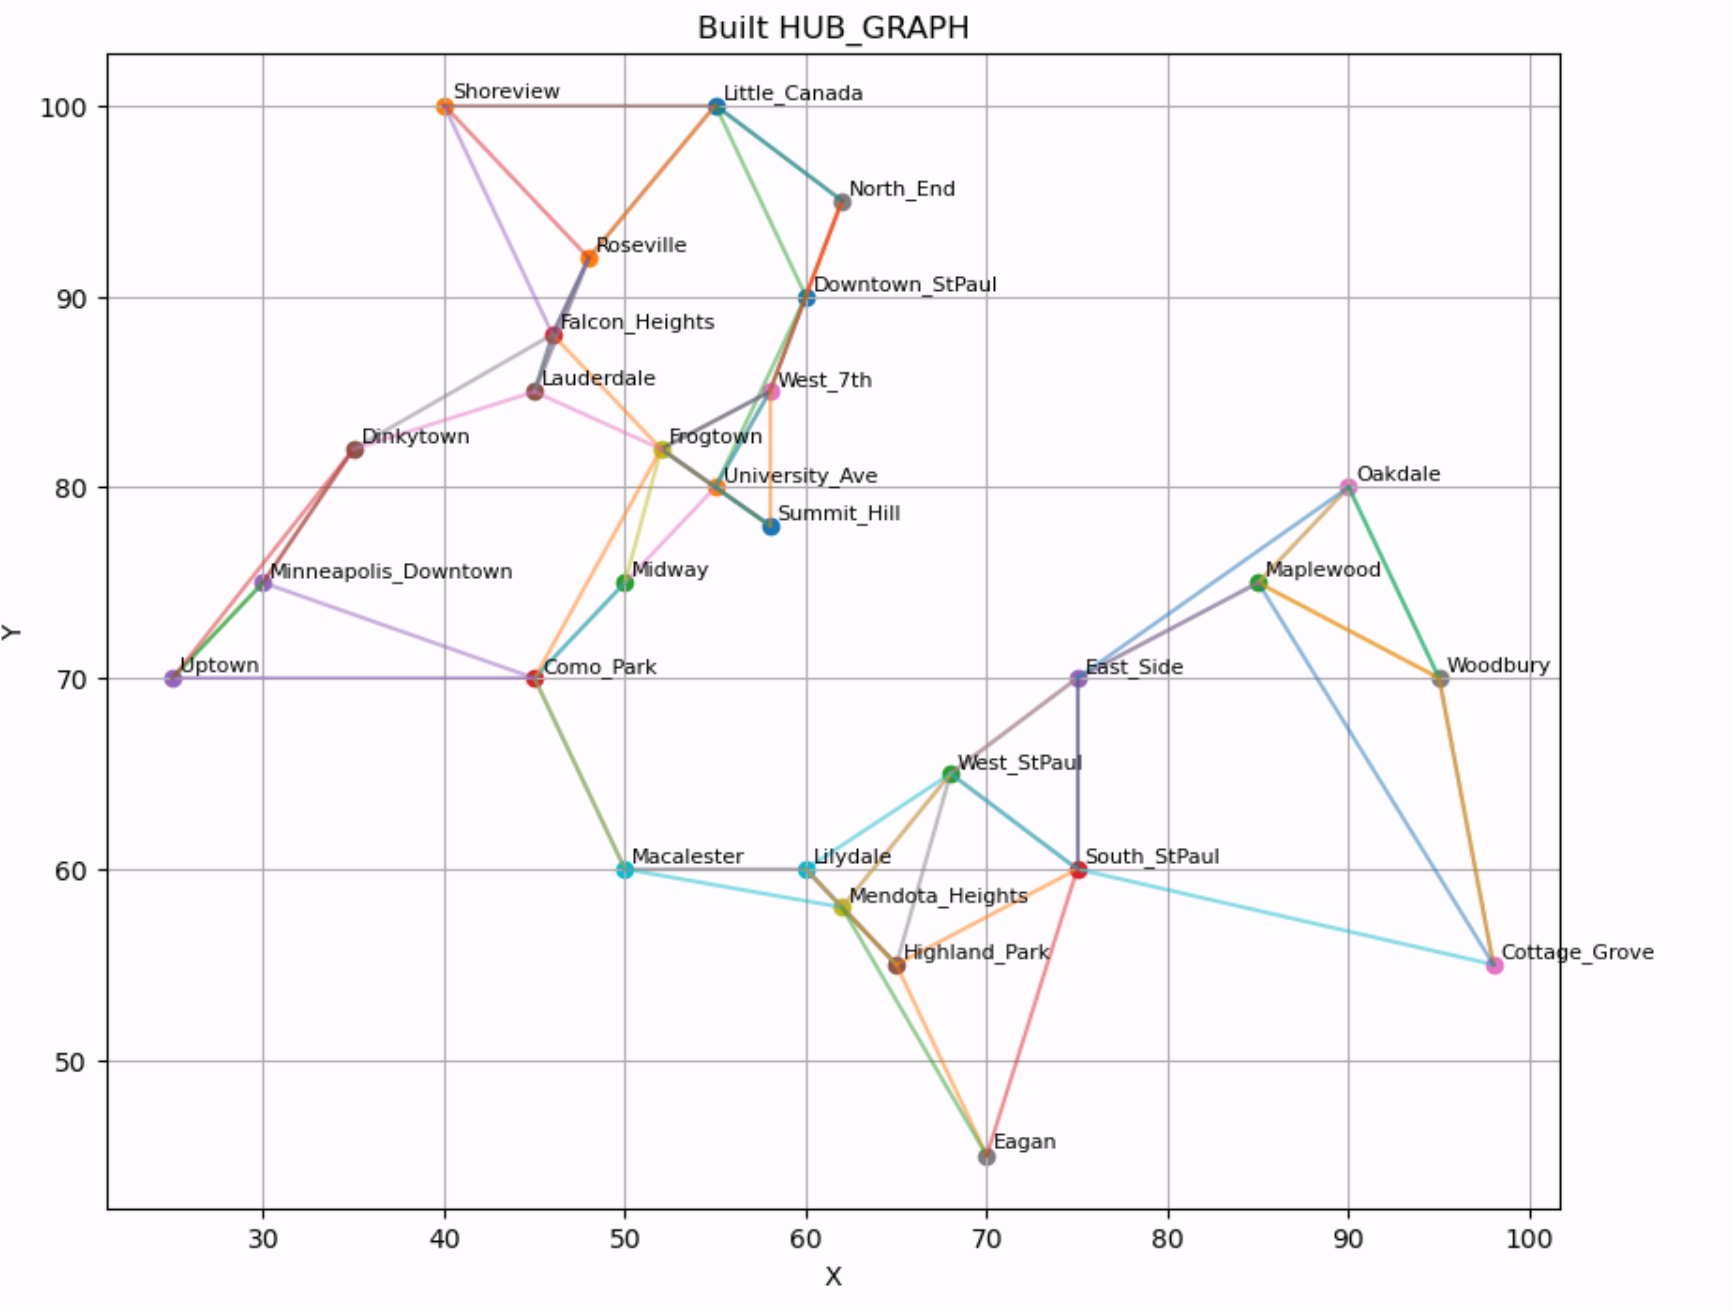

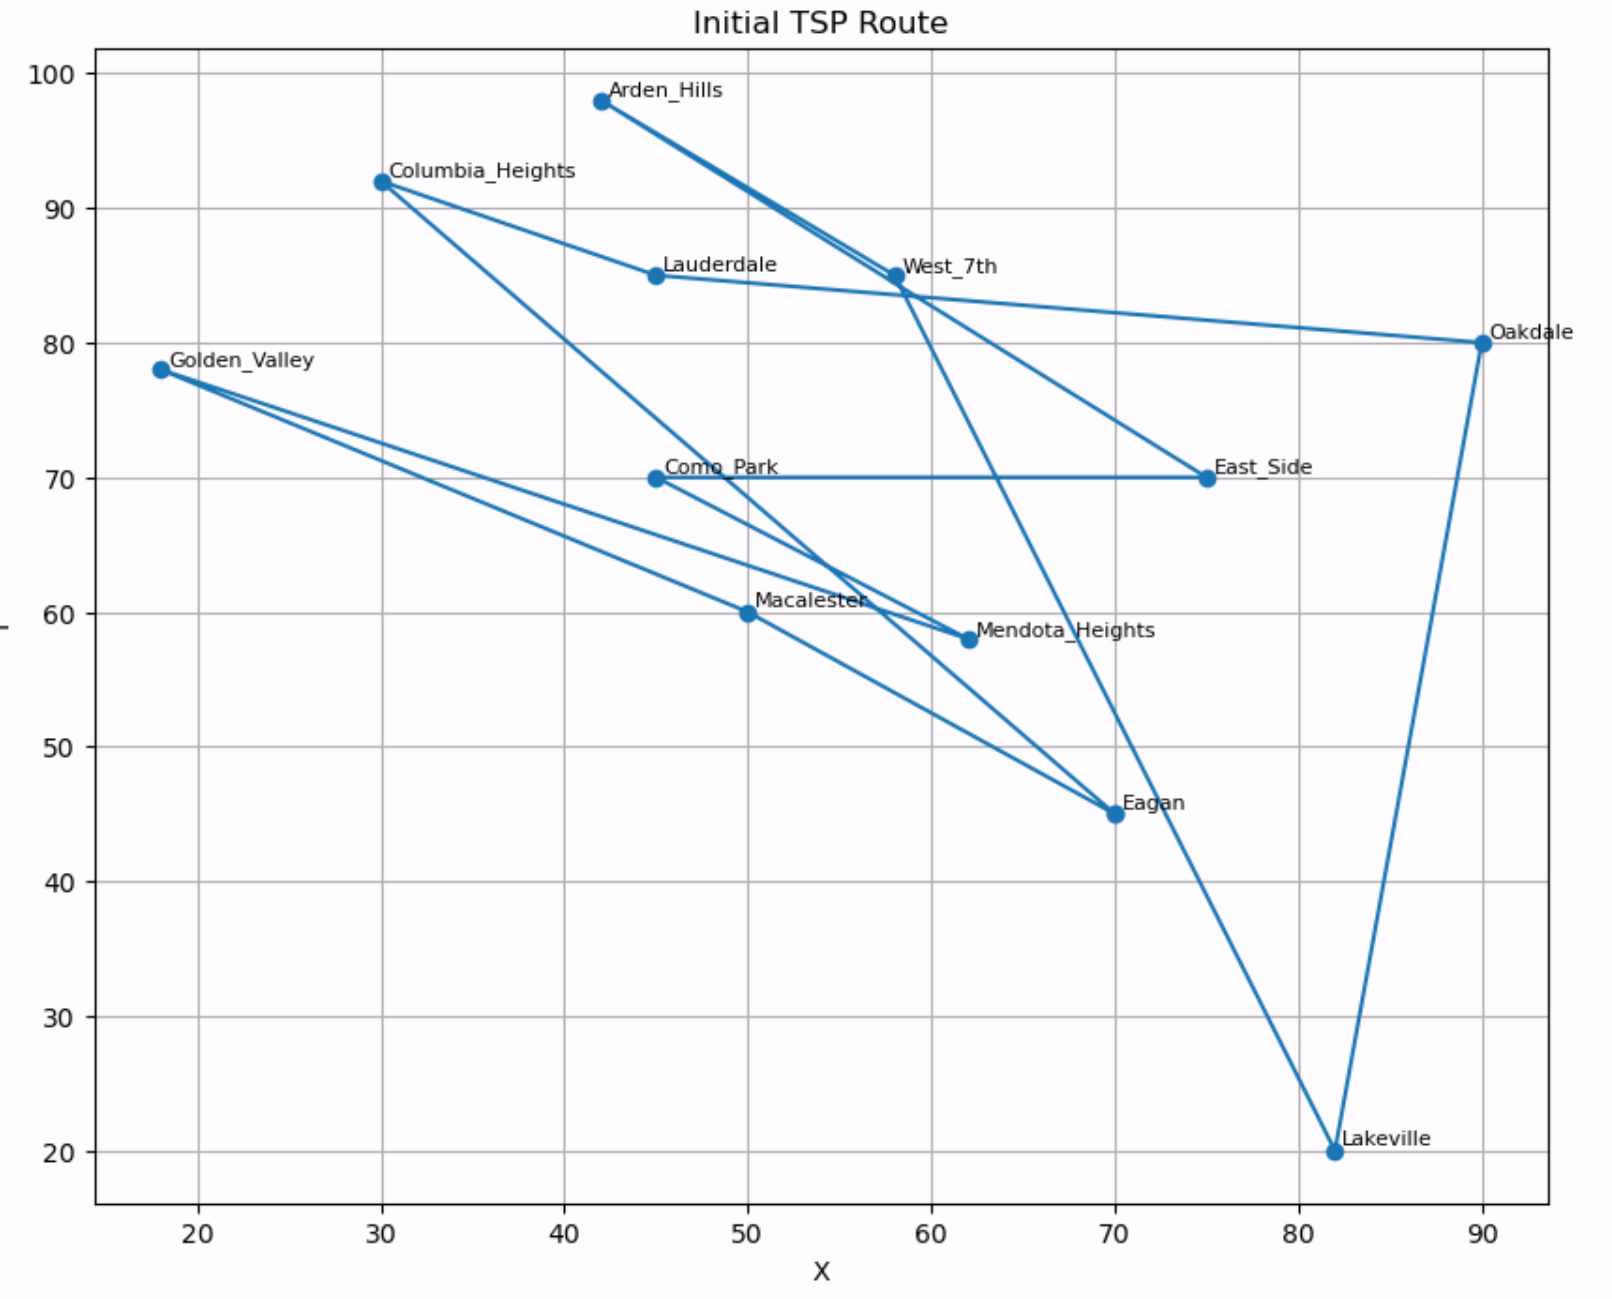

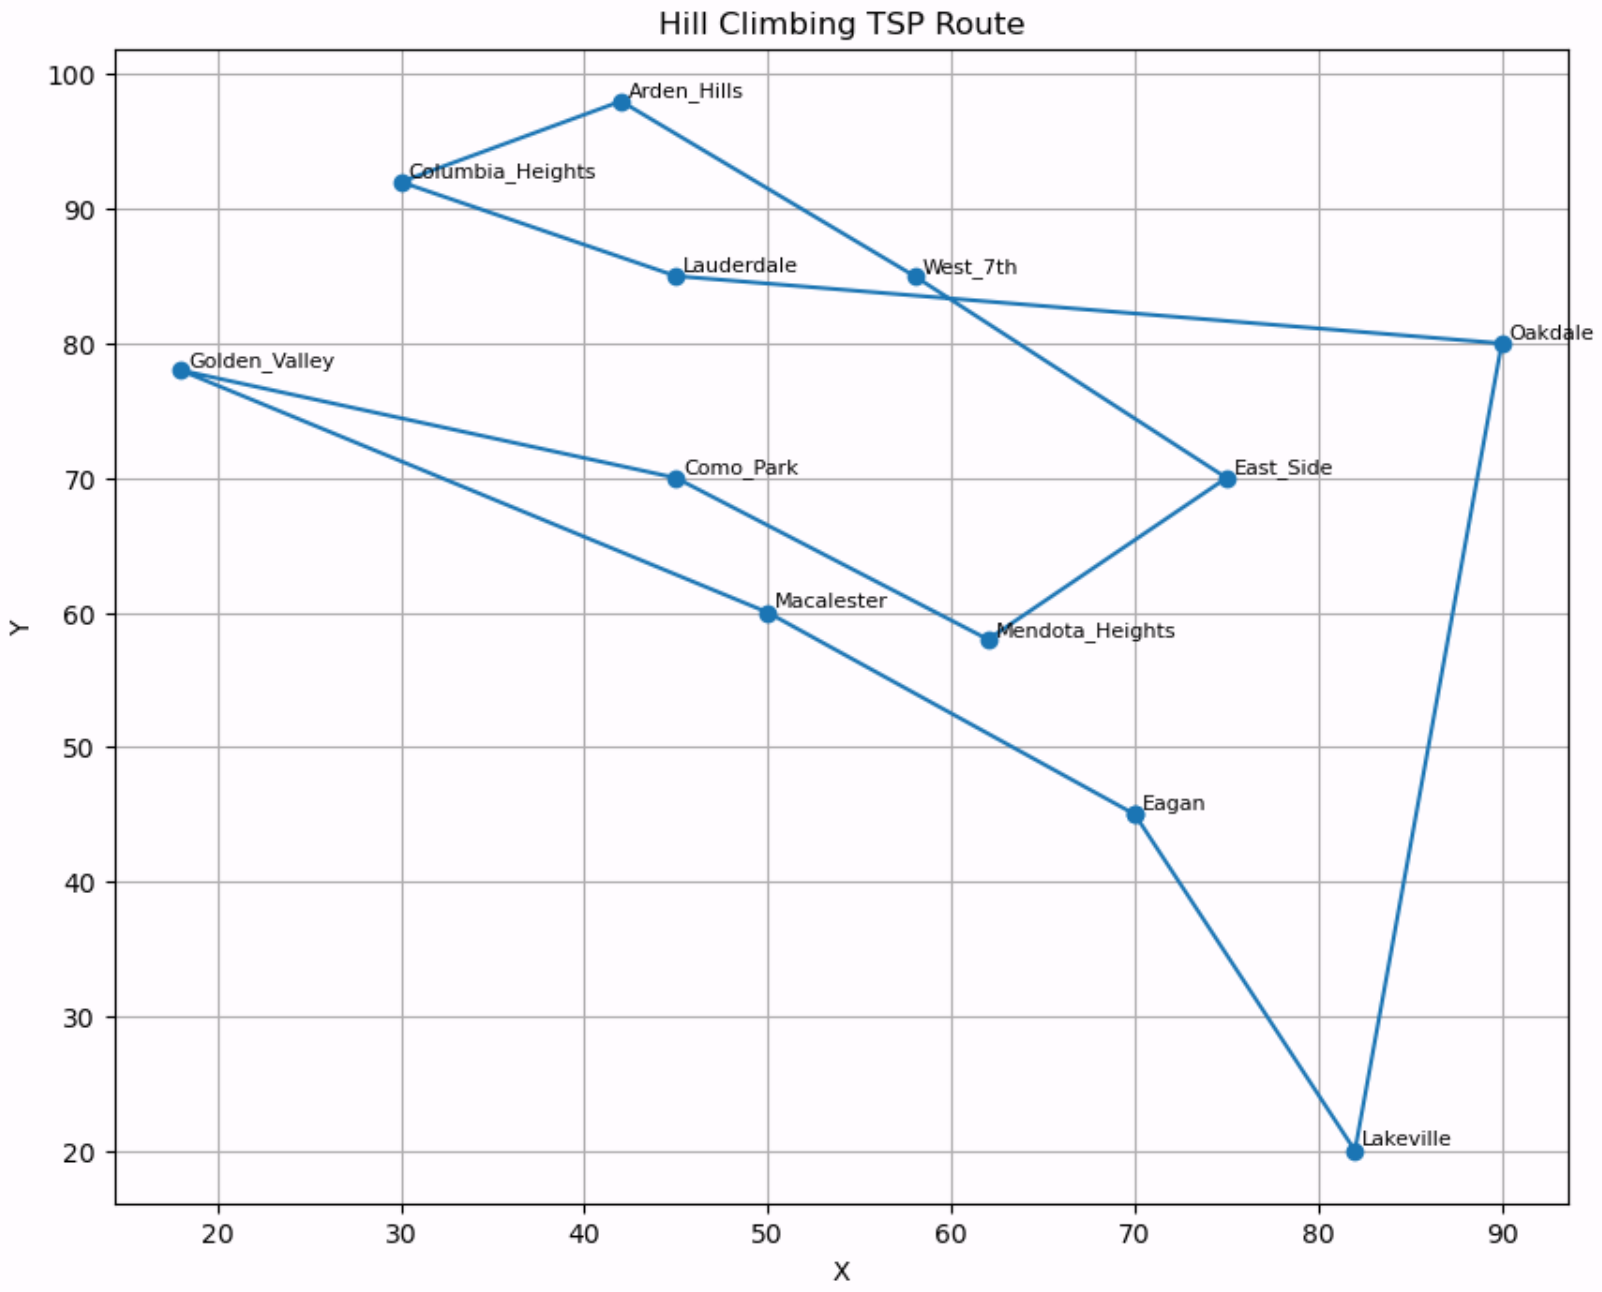

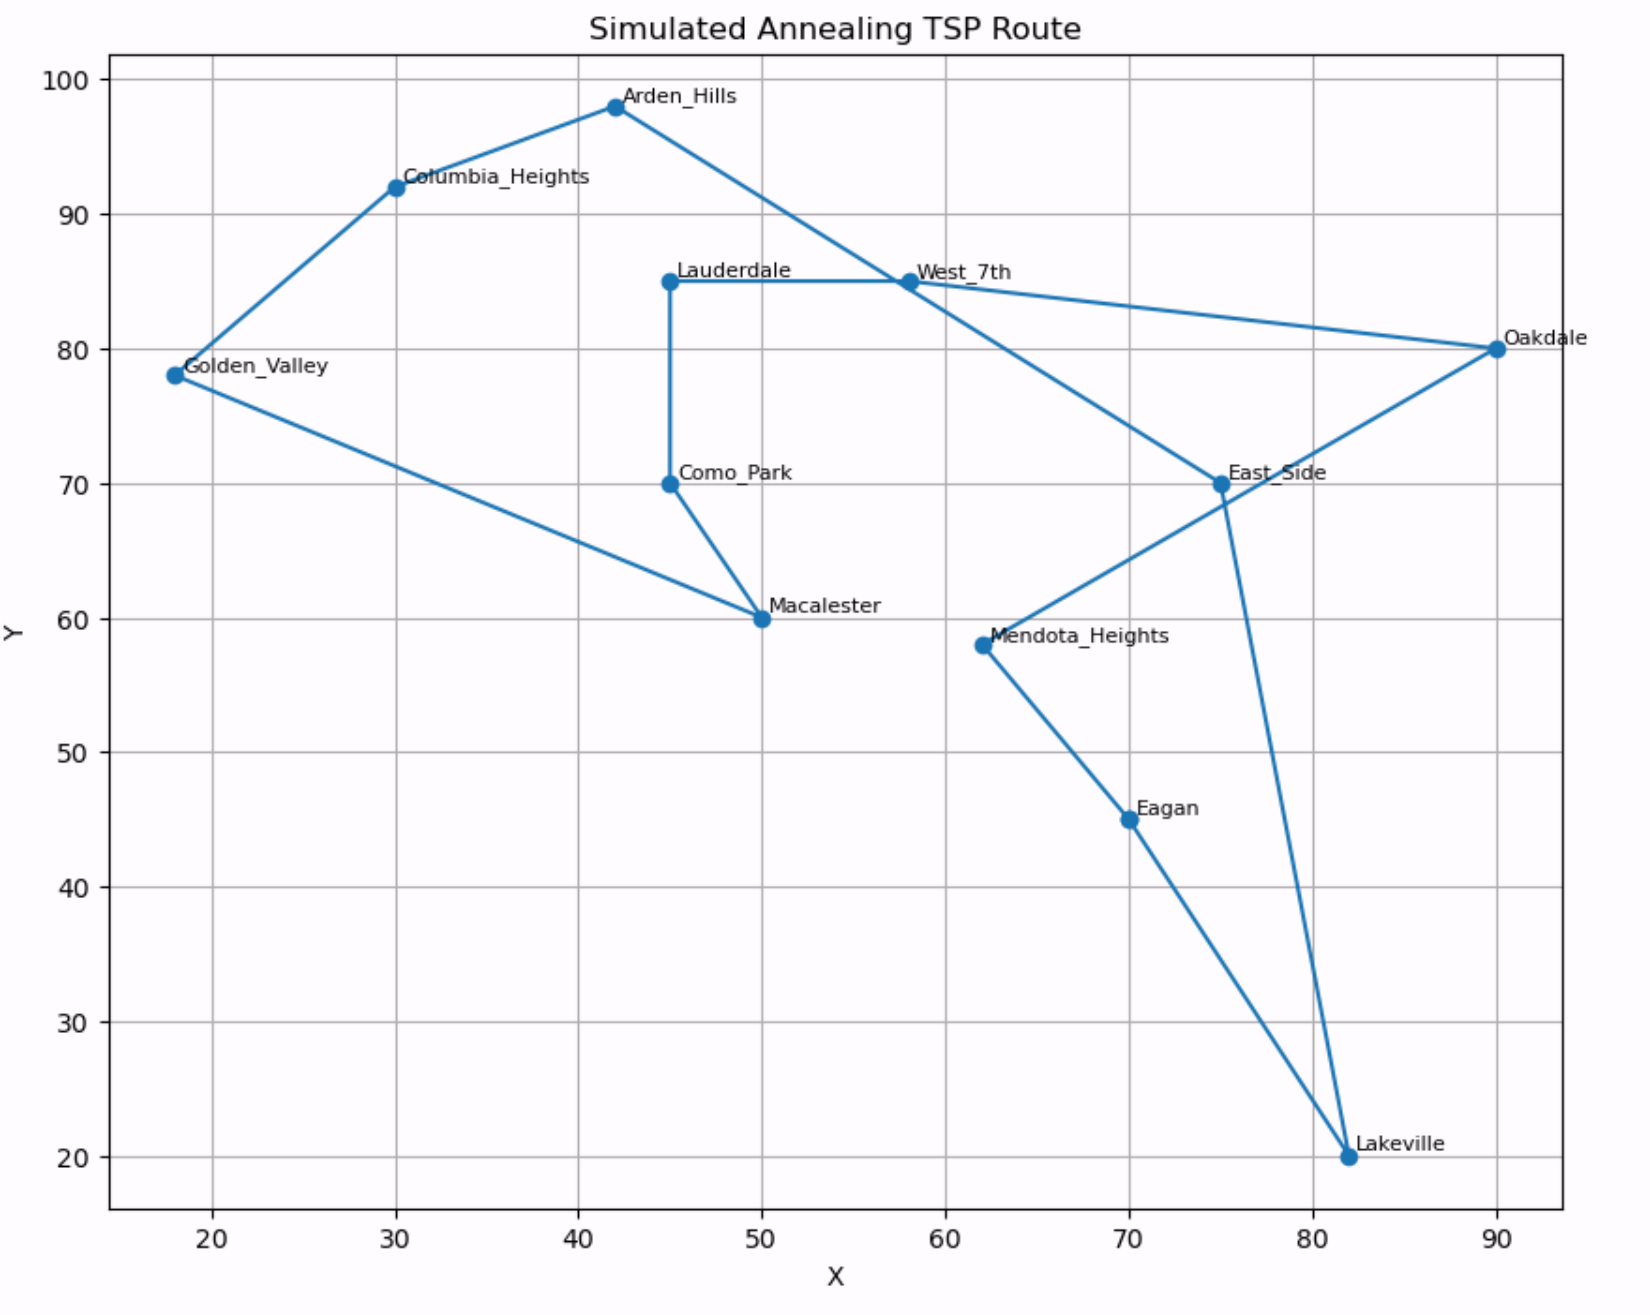

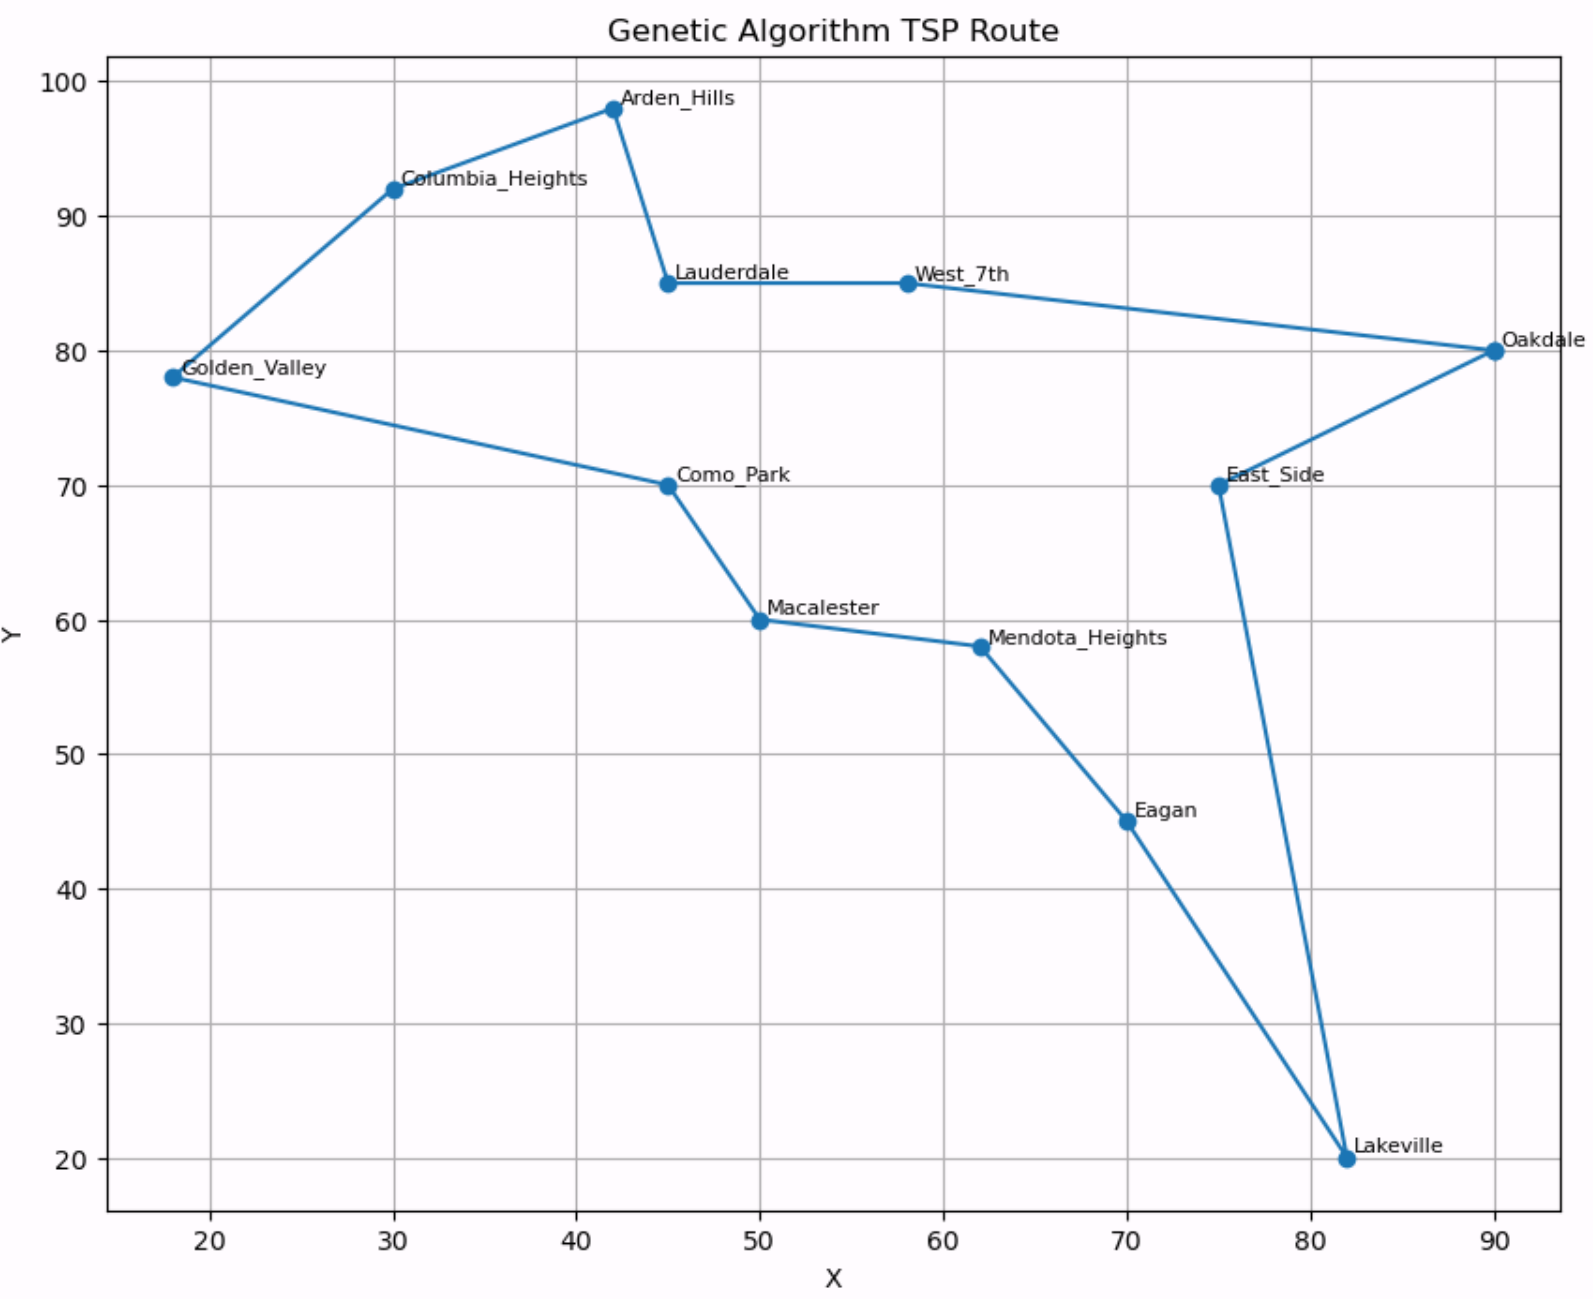